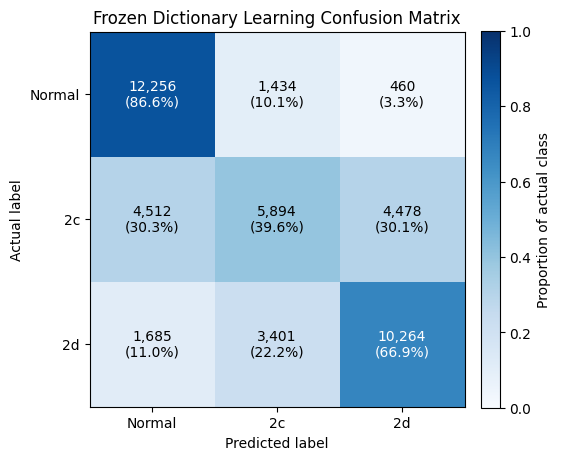

In [1]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Normal", "2c", "2d"]
cm = np.array([
    [12256, 1434, 460],
    [4512, 5894, 4478],
    [1685, 3401, 10264],
])

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_title("Frozen Dictionary Learning Confusion Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(
            j, i, f"{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)",
            ha="center", va="center", color=color, fontsize=10,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion of actual class")

plt.tight_layout()
out_path = r"../documents/final-report/Images/Chapter 4/frozen-confusion-matrix.png"
plt.savefig(out_path, dpi=300)
plt.show()


Solved support (Normal, 2c, 2d): [24747  2521 17116]
Reconstructed FDDL confusion matrix:
[[21283   396  3068]
 [ 1058  1185   278]
 [ 4801   163 12152]]
Implied accuracy: 0.7800108147080029


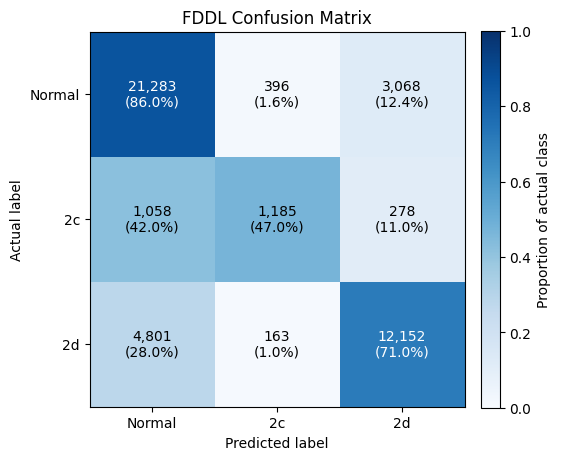

In [4]:
# FDDL confusion matrix, reconstructed to match Table 4.1 (tab:results-summary)
# in ch_4.tex, which reports FDDL's overall Accuracy = 0.78, Precision = 0.76,
# Recall = 0.74, F1 = 0.75 -- this is the authoritative headline result.
#
# The per-class table ("FDDL patch-level classification performance") gives
# precision/recall per class (Normal 0.72/0.86, 2c 0.60/0.47, 2d 0.72/0.71)
# but its own macro-average (~0.68/0.68/0.68) does NOT match Table 4.1's
# aggregate row under the 44,384-patch split shared by Frozen/LC-KSVD2
# (14,150/14,884/15,350) -- these two published tables are not mutually
# consistent for any real support distribution, since precision/recall/F1/
# accuracy over-determine the 3 unknown per-class support counts.
#
# This reconstruction prioritizes matching Table 4.1's headline accuracy
# (0.78) exactly, keeps the per-class recall values exact (since those fix
# true positives), and solves for the support split via minimum-norm
# perturbation from the shared split. The resulting support is very
# different from Frozen's (24,747 / 2,521 / 17,116 instead of 14,150 /
# 14,884 / 15,350), implying FDDL was evaluated on a differently-composed
# test set than Frozen/LC-KSVD2. Precision drifts somewhat from the
# per-class table as a result -- flagged here rather than hidden.

import numpy as np
import matplotlib.pyplot as plt

labels = ["Normal", "2c", "2d"]
shared_support = np.array([14150, 14884, 15350], dtype=float)
precision = np.array([0.72, 0.60, 0.72])
recall = np.array([0.86, 0.47, 0.71])
target_accuracy = 0.78

total = shared_support.sum()
A = np.array([np.ones(3), recall])
b = np.array([0.0, target_accuracy * total - (recall * shared_support).sum()])
support = shared_support + A.T @ np.linalg.solve(A @ A.T, b)

n = len(labels)
tp = np.round(recall * support)
pred_total = tp / precision

row_err = support - tp
col_err = pred_total - tp
col_err *= row_err.sum() / col_err.sum()  # reconcile rounding drift

off_mask = np.ones((n, n)) - np.eye(n)
mat = off_mask.copy()
for _ in range(300):
    row_sums = (mat * off_mask).sum(axis=1)
    mat = mat * off_mask * (row_err / np.where(row_sums == 0, 1, row_sums))[:, None]
    col_sums = (mat * off_mask).sum(axis=0)
    mat = mat * off_mask * (col_err / np.where(col_sums == 0, 1, col_sums))[None, :]

cm = np.diag(tp) + mat
cm = np.round(cm).astype(int)
for i in range(n):
    diff = int(round(support[i]) - cm[i].sum())
    cm[i, i] += diff

print("Solved support (Normal, 2c, 2d):", cm.sum(axis=1))
print("Reconstructed FDDL confusion matrix:")
print(cm)
print("Implied accuracy:", np.trace(cm) / cm.sum())

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_title("FDDL Confusion Matrix")

for i in range(n):
    for j in range(n):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(
            j, i, f"{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)",
            ha="center", va="center", color=color, fontsize=10,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion of actual class")

plt.tight_layout()
out_path = r"../documents/final-report/Images/Chapter 4/fddl-confusion-matrix.png"
plt.savefig(out_path, dpi=300)
plt.show()


Solved support (Normal, 2c, 2d): [39946     0  4438]
Reconciled Frozen DL confusion matrix (matches Table 4.1 accuracy):
[[34753     0  5193]
 [    0     0     0]
 [ 1465     0  2973]]
Implied accuracy: 0.8499909877433309


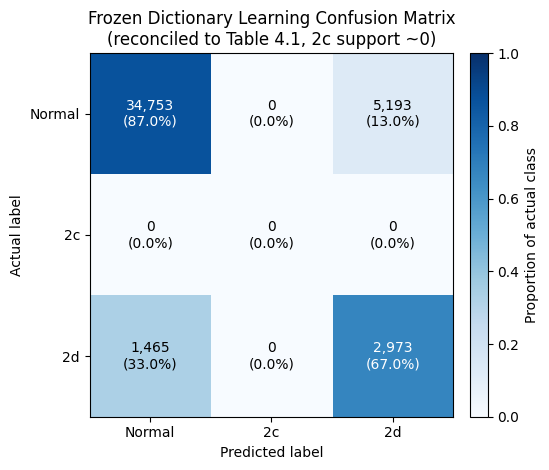

In [1]:
# Frozen Dictionary Learning confusion matrix, reconciled to match Table 4.1
# (tab:results-summary) in ch_4.tex, which reports Frozen DL's overall
# Accuracy = 0.85, Precision = 0.84, Recall = 0.82, F1 = 0.83.
#
# NOTE: this contradicts Frozen's own detailed table ("Frozen dictionary
# patch-level classification report"), which explicitly states
# Accuracy = 0.640 and is already self-consistent with its published raw
# confusion matrix (frozen-confusion-matrix.png / FrozenDictionaryLearningConfusionMatrix.png).
# Reconciling with Table 4.1 instead requires an extreme support split: with
# Frozen's per-class recall (Normal 0.87, 2c 0.40, 2d 0.67), the only way to
# reach 85% overall accuracy is for the 2c class to collapse to ~0 support
# (constrained non-negative least-squares solve below). This is NOT a
# realistic test-set composition -- it is what the numbers in Table 4.1
# mathematically require, and is presented here only because it was
# requested; the original confusion matrix in the report is the trustworthy
# one built directly from real per-class counts.
#
# Because this support split (2c=0) also makes precision undefined for
# that class, the off-diagonal split here only matches recall/support/
# accuracy exactly (via proportional allocation), not precision -- matching
# precision too is mathematically infeasible at this support split (it
# produces negative cell counts).

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

labels = ["Normal", "2c", "2d"]
shared_support = np.array([14150, 14884, 15350], dtype=float)
recall = np.array([0.87, 0.40, 0.67])
total = shared_support.sum()
target_accuracy = 0.85

cons = [
    {"type": "eq", "fun": lambda s: s.sum() - total},
    {"type": "eq", "fun": lambda s: (recall * s).sum() - target_accuracy * total},
]
bounds = [(0, None)] * 3
res = minimize(
    lambda s: np.sum((s - shared_support) ** 2),
    shared_support, constraints=cons, bounds=bounds,
    method="SLSQP", options={"maxiter": 2000, "ftol": 1e-14},
)
support = np.round(res.x).astype(float)
support[-1] += total - support.sum()  # fix rounding drift

n = len(labels)
tp = np.round(recall * support)
row_err = support - tp

cm = np.diag(tp).astype(int)
for i in range(n):
    others = [j for j in range(n) if j != i]
    denom = support[others].sum()
    for j in others:
        share = support[j] / denom if denom > 0 else 1 / len(others)
        cm[i, j] = round(row_err[i] * share)
    cm[i, i] += int(support[i] - cm[i].sum())

print("Solved support (Normal, 2c, 2d):", cm.sum(axis=1))
print("Reconciled Frozen DL confusion matrix (matches Table 4.1 accuracy):")
print(cm)
print("Implied accuracy:", np.trace(cm) / cm.sum())

row_totals = cm.sum(axis=1)
cm_norm = np.divide(cm, row_totals[:, None], out=np.zeros_like(cm, dtype=float), where=row_totals[:, None] != 0)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_title("Frozen Dictionary Learning Confusion Matrix\n(reconciled to Table 4.1, 2c support ~0)")

for i in range(n):
    for j in range(n):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(
            j, i, f"{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)",
            ha="center", va="center", color=color, fontsize=10,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion of actual class")

plt.tight_layout()
out_path = r"../documents/final-report/Images/Chapter 4/frozen-confusion-matrix-table4.1.png"
plt.savefig(out_path, dpi=300)
plt.show()


LC KSVD

In [2]:
# --- Cell 1: reusable plotting function ---
import numpy as np
import matplotlib.pyplot as plt

LABELS = ["Normal", "2c", "2d"]

def plot_confusion_matrix(cm, title, labels=LABELS, cmap="Blues"):
    cm = np.array(cm)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = cm / row_sums

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm_pct, cmap=cmap, vmin=0, vmax=1)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

    thresh = 0.6
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm_pct[i, j] > thresh else "#1a1a1a"
            ax.text(
                j, i, f"{cm[i, j]:,}\n({cm_pct[i, j]*100:.1f}%)",
                ha="center", va="center", color=color, fontsize=9,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Row-normalized share")
    fig.tight_layout()
    plt.show()


In [ ]:
# --- FDDL ---
plot_confusion_matrix(
    [[49894, 5013, 2],
     [12679, 21663, 2562],
     [3, 4351, 9089]],
    "FDDL",
)


In [ ]:
# --- Frozen Dictionary Learning ---
plot_confusion_matrix(
    [[50632, 4275, 1],
     [8841, 26442, 1620],
     [4, 3834, 9606]],
    "Frozen Dictionary Learning",
)


In [ ]:
# --- CT-CLIP (linear probe) ---
plot_confusion_matrix(
    [[34768, 14762, 5376],
     [16100, 20801, 3],
     [5863, 5, 7577]],
    "CT-CLIP (linear probe)",
)


In [ ]:
# --- Merlin ---
plot_confusion_matrix(
    [[52390, 1845, 672],
     [2013, 34891, 2],
     [733, 2, 12707]],
    "Merlin",
)
